In [ ]:
from google.colab import drive
drive.mount('/content/drive')

zip_file_path = "/content/drive/MyDrive/Datasets/Copy of devnagari digit.zip"
extract_path = "/content/"

# Unzip the file silently (-q) to the specified extraction path (-d)
!unzip -q "{zip_file_path}" -d "{extract_path}"
print(f"Successfully extracted '{zip_file_path}' to '{extract_path}'.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
unzip:  cannot find or open /content/drive/MyDrive/Datasets/Copy of devnagari digit.zip, /content/drive/MyDrive/Datasets/Copy of devnagari digit.zip.zip or /content/drive/MyDrive/Datasets/Copy of devnagari digit.zip.ZIP.
Successfully extracted '/content/drive/MyDrive/Datasets/Copy of devnagari digit.zip' to '/content/'.


## Part 1: MNIST Dataset with Simple Neural Network (SGD optimizer)

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train, x_test = x_train / 255.0, x_test / 255.0
print(x_train.shape)

x_train = x_train.reshape(-1, 28 * 28)
x_test = x_test.reshape(-1, 28 * 28)

y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)
print(y_test)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28)
[[0. 0. 0. ... 1. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [ ]:
import tensorflow as tf
from tensorflow import keras

num_classes = 10
input_shape = (28 * 28,)

model = keras.Sequential(
    [
        keras.layers.Input(shape=input_shape),
        keras.layers.Flatten(),
        keras.layers.Dense(64, activation="sigmoid"),
        keras.layers.Dense(128, activation="sigmoid"),
        keras.layers.Dense(256, activation="sigmoid"),
        keras.layers.Dense(num_classes, activation="softmax"),
    ]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="sgd",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
batch_size = 128
epochs = 20

callbacks = [
    keras.callbacks.ModelCheckpoint(filepath="model_at_epoch_{epoch}.keras"),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=4),
]

history = model.fit(
    x_train,
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.2,
    callbacks=callbacks,
)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.1117 - loss: 2.3071 - val_accuracy: 0.1060 - val_loss: 2.3023
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.1150 - loss: 2.3007 - val_accuracy: 0.1060 - val_loss: 2.3021
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.1160 - loss: 2.2995 - val_accuracy: 0.1845 - val_loss: 2.2997
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.1189 - loss: 2.2982 - val_accuracy: 0.1684 - val_loss: 2.2975
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.1236 - loss: 2.2969 - val_accuracy: 0.1060 - val_loss: 2.2972
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.1249 - loss: 2.2956 - val_accuracy: 0.1258 - val_loss: 2.2953
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.1286 - loss: 2.2936 - val_accuracy: 0.1060 - val_loss: 2.2936
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.1334 - loss: 2.2921 - val_accuracy: 0.

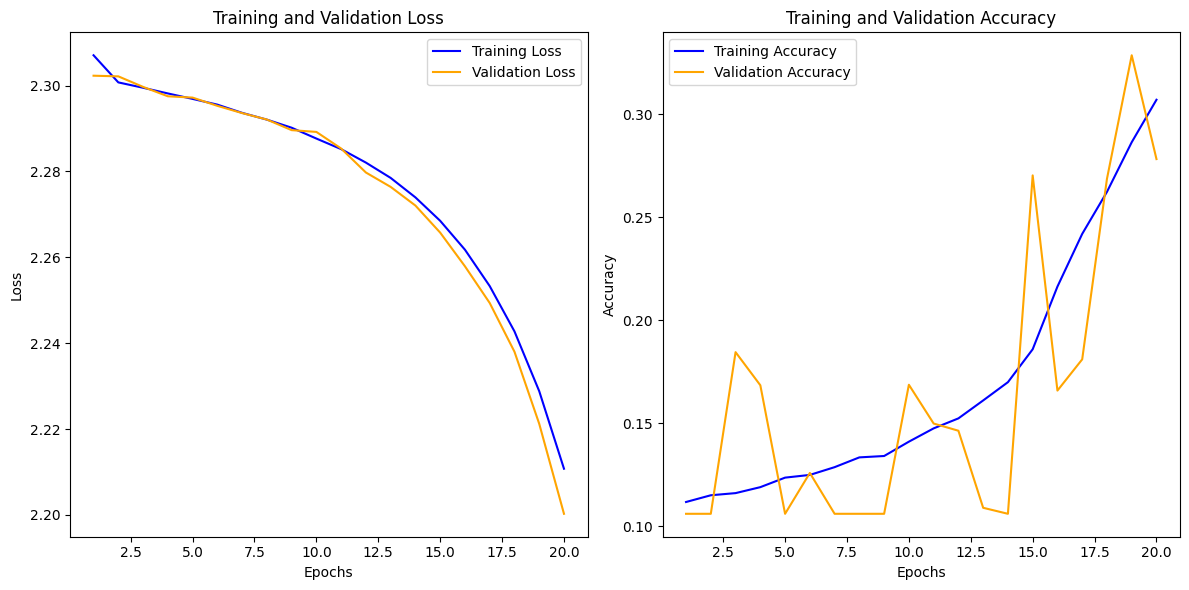

In [ ]:
import matplotlib.pyplot as plt

train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_loss) + 1), train_loss, label='Training Loss', color='blue')
plt.plot(range(1, len(val_loss) + 1), val_loss, label='Validation Loss', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_acc) + 1), train_acc, label='Training Accuracy', color='blue')
plt.plot(range(1, len(val_acc) + 1), val_acc, label='Validation Accuracy', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

## Part 2: Devanagari Handwritten Digit Dataset

In [ ]:
import os
import numpy as np
from PIL import Image

def one_hot_encode(labels, num_classes):
    return np.eye(num_classes)[labels]

def load_dataset(folder_path, img_size=(28, 28)):
    images = []
    labels = []
    class_names = []

    # Sort classes to keep label order consistent
    classes = sorted(os.listdir(folder_path))

    for label, class_name in enumerate(classes):
        class_path = os.path.join(folder_path, class_name)
        if os.path.isdir(class_path):
            class_names.append(class_name)
            for file in os.listdir(class_path):
                img_path = os.path.join(class_path, file)
                try:
                    # Load image using PIL
                    img = Image.open(img_path).convert("RGB")
                    # Resize image
                    img = img.resize(img_size)
                    # Convert to numpy & normalize (0-1)
                    img_array = np.array(img) / 255.0
                    images.append(img_array)
                    labels.append(label)
                except:
                    continue  # skip bad files

    return np.array(images), np.array(labels), class_names

In [12]:
train_path = "/content/drive/MyDrive/Train"
X_train, y_train, class_names = load_dataset(train_path)

# One-hot encode labels
y_train_encoded = one_hot_encode(y_train, len(class_names))

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train_encoded.shape)
print("Classes:", class_names)

X_train shape: (5308, 28, 28, 3)
y_train shape: (5308, 10)
Classes: ['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']


In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
test_path = "/content/drive/MyDrive/Test"
X_test, y_test, _ = load_dataset(test_path)
y_test_encoded = one_hot_encode(y_test, len(class_names))

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test_encoded.shape)

X_test shape: (3000, 28, 28, 3)
y_test shape: (3000, 10)


In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

model = Sequential([
    Flatten(input_shape=(28, 28, 3)),
    Dense(64, activation='sigmoid'),
    Dense(128, activation='sigmoid'),
    Dense(256, activation='sigmoid'),
    Dense(10, activation='softmax')
])

model.summary()

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',  # because of one-hot encoding
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 2352)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       150,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 194,506 (759.79 KB)

 Trainable params: 194,506 (759.79 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor='val_loss',
    save_best_only=True
)

history = model.fit(
    X_train,
    y_train_encoded,
    batch_size=128,
    epochs=20,
    validation_split=0.2,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4726 - loss: 1.5263

34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.6540 - loss: 1.1972 - val_accuracy: 0.0000e+00 - val_loss: 1.5318
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8277 - loss: 0.5930

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8794 - loss: 0.4565 - val_accuracy: 0.8305 - val_loss: 0.7209
Epoch 3/20
31/34 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9472 - loss: 0.2047

34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9475 - loss: 0.1727 - val_accuracy: 0.8795 - val_loss: 0.5257
Epoch 4/20
30/34 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9592 - loss: 0.1104

34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9753 - loss: 0.0951 - val_accuracy: 0.8964 - val_loss: 0.3753
Epoch 5/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9981 - loss: 0.0511 - val_accuracy: 0.8738 - val_loss: 0.3835
Epoch 6/20
30/34 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9991 - loss: 0.0332

34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9988 - loss: 0.0284 - val_accuracy: 0.8757 - val_loss: 0.3507
Epoch 7/20
33/34 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9995 - loss: 0.0192

34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9998 - loss: 0.0164 - val_accuracy: 0.8879 - val_loss: 0.3260
Epoch 8/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 1.0000 - loss: 0.0106 - val_accuracy: 0.8729 - val_loss: 0.3726
Epoch 9/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 1.0000 - loss: 0.0073 - val_accuracy: 0.8823 - val_loss: 0.3447
Epoch 10/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 1.0000 - loss: 0.0054 - val_accuracy: 0.8748 - val_loss: 0.3744


In [16]:
test_loss, test_accuracy = model.evaluate(X_test, y_test_encoded)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3587 - loss: 6.0470
Test Loss: 6.0470170974731445
Test Accuracy: 0.35866665840148926


In [17]:
model.save("finalmodel.h5")

In [18]:
from tensorflow.keras.models import load_model

loaded_model = load_model("finalmodel.h5")

loss, acc = loaded_model.evaluate(X_test, y_test_encoded)
print("Loaded Model Accuracy:", acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3587 - loss: 6.0470
Loaded Model Accuracy: 0.35866665840148926


94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


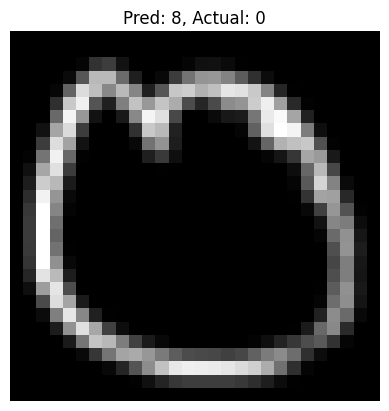

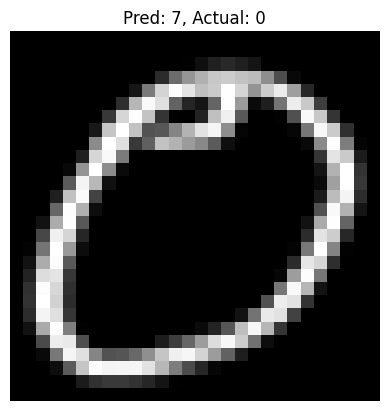

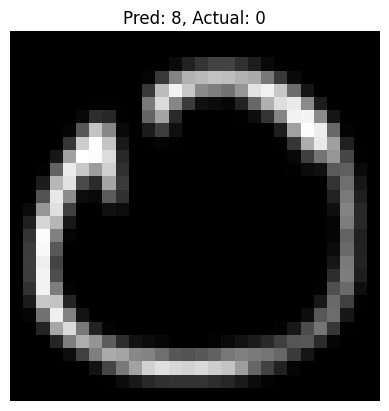

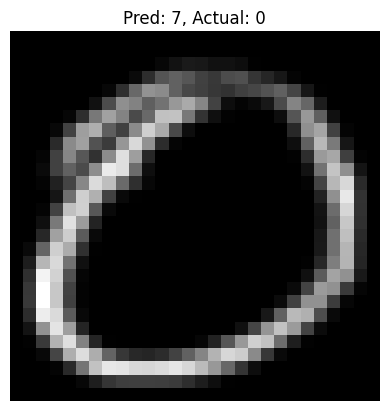

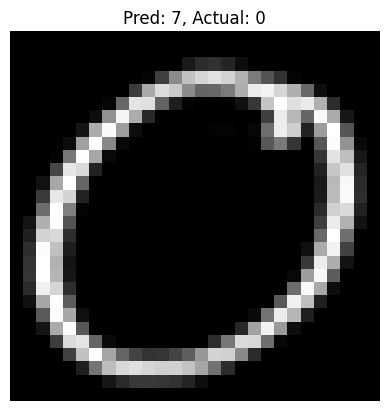

In [19]:
predictions = loaded_model.predict(X_test)

predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test_encoded, axis=1)

import matplotlib.pyplot as plt

for i in range(5):
    plt.imshow(X_test[i])
    plt.title(f"Pred: {predicted_labels[i]}, Actual: {true_labels[i]}")
    plt.axis("off")
    plt.show()